In [2]:
# # After installation, comment this cell and restart the kernel
# !pip3 install pandas pillow imagehash matplotlib scikit-learn torch torchvision

### TODO/PLAN:

##### EDA:
Show brightness, resolution, quality distribution

For each class, need to do augmentation, 
i.e. 
- 1 image -> flip -> another img (for deadly - 1200 images)
- 1 image -> rotation -> another img (for deadly - 1200 images)
- 1 image -> color jittering -> another img (for deadly - 1200 images)
  
total we have 4800 images for dealy to train\
Create different transformer for each augmentation step.

Undersample majority classes to like 4800 images using random selection or some libraries

Train-test-split (0.8, 0.15, 0.15)

##### Setup models
1. weighted w/ imbalanced dataset (JoJo's dataset) - resNet18(Daphne ✅), resNet50 (JoJo), Swim (Nick)
2. non-weighted w/ balanced dataset (JoJo's dataset + further processing) - resNet18 (Daphne), resNet50 (JoJo), Swim (Nick)

show top k images that performed worse in the model, and why it performed badly (mention in report)



In [1]:
# import necessary libraries
import pandas as pd
from pathlib import Path
from PIL import Image
import imagehash
import matplotlib.pyplot as plt
from collections import defaultdict
from torchvision import transforms
from torchvision import models
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, classification_report, balanced_accuracy_score

torch.backends.cudnn.benchmark = True
torch.set_float32_matmul_precision("high")

### Prepare Metadata CSV

In [3]:
ROOT = Path("./Classes")
# Some paths have depth of 4 instead of 3, need to list them all out
files = [f for f in ROOT.rglob("*") if f.is_file() and not f.name.startswith(".")]
print("Total files found:", len(files))

Total files found: 102713


In [4]:
pd.set_option('display.max_colwidth', 100)

In [5]:
data = []

In [ ]:
# This cell may take a long time to run, to speed up, we can directly read from the processed mushroom_paths.csv file
for f in files:
    try:
        with Image.open(f) as img:
            w, h = img.size
            img_hash = imagehash.phash(img)
    except Exception:
        continue

    data.append([
        str(f),
        len(f.relative_to(ROOT).parts),
        f.stem,
        f.suffix.lstrip("."),
        w,
        h,
        w * h,
        img_hash
    ])

df = pd.DataFrame(
    data,
    columns=["file_path", "depth", "file_name", "file_ext", "width", "height", "num_pixels", "phash"]
)

df["aspect_ratio"] = df["width"] / df["height"]

In [6]:
# This above cell may take a long time to run, to speed up, we can directly read from the processed mushroom_paths.csv file
if len(data) == 0:
    df = pd.read_csv("mushroom_paths.csv")

In [7]:
df.shape

(102711, 11)

In [8]:
df.head()

,file_path,depth,file_name,file_ext,width,height,num_pixels,phash,aspect_ratio,class,species
0,Classes/conditionally_edible/horn_of_plenty/8.png,3,8,png,512,512,262144,abb9d4a0aae5c4d4,1.0,conditionally_edible,horn_of_plenty
1,Classes/conditionally_edible/horn_of_plenty/9.png,3,9,png,512,512,262144,a581b66e5c2d6b32,1.0,conditionally_edible,horn_of_plenty
2,Classes/conditionally_edible/horn_of_plenty/14.png,3,14,png,512,512,262144,d8f40799f31ea870,1.0,conditionally_edible,horn_of_plenty
3,Classes/conditionally_edible/horn_of_plenty/12.png,3,12,png,512,512,262144,a8a8e950d4af3f58,1.0,conditionally_edible,horn_of_plenty
4,Classes/conditionally_edible/horn_of_plenty/13.png,3,13,png,512,512,262144,8e86638cdcad5bd0,1.0,conditionally_edible,horn_of_plenty


In [18]:
print("File Depth Distribution:")
print(df.groupby('depth').size())

File Depth Distribution:
depth
3    95998
4     6713
dtype: int64


In [19]:
print("\nSample files with depth 3:")
df[df['depth'] == 3].head()


Sample files with depth 3:


,file_path,depth,file_name,file_ext,width,height,num_pixels,phash,aspect_ratio,class,species
0,Classes/conditionally_edible/horn_of_plenty/8.png,3,8,png,512,512,262144,abb9d4a0aae5c4d4,1.0,conditionally_edible,horn_of_plenty
1,Classes/conditionally_edible/horn_of_plenty/9.png,3,9,png,512,512,262144,a581b66e5c2d6b32,1.0,conditionally_edible,horn_of_plenty
2,Classes/conditionally_edible/horn_of_plenty/14.png,3,14,png,512,512,262144,d8f40799f31ea870,1.0,conditionally_edible,horn_of_plenty
3,Classes/conditionally_edible/horn_of_plenty/12.png,3,12,png,512,512,262144,a8a8e950d4af3f58,1.0,conditionally_edible,horn_of_plenty
4,Classes/conditionally_edible/horn_of_plenty/13.png,3,13,png,512,512,262144,8e86638cdcad5bd0,1.0,conditionally_edible,horn_of_plenty


In [20]:
print("\nSample files with depth 4:")
df[df['depth'] == 4].head()


Sample files with depth 4:


,file_path,depth,file_name,file_ext,width,height,num_pixels,phash,aspect_ratio,class,species
20454,Classes/conditionally_edible/Mushrooms/Agaricus/251_J9uSJkkBULQ.jpg,4,251_J9uSJkkBULQ,jpg,800,531,424800,cedf756430330339,1.506591,conditionally_edible,Agaricus
20455,Classes/conditionally_edible/Mushrooms/Agaricus/357__w_XUQZMZEw.jpg,4,357__w_XUQZMZEw,jpg,800,600,480000,c6d879863d364b29,1.333333,conditionally_edible,Agaricus
20456,Classes/conditionally_edible/Mushrooms/Agaricus/374_Xap1L15Z8BM.jpg,4,374_Xap1L15Z8BM,jpg,777,600,466200,c6966b613cc68dcc,1.295000,conditionally_edible,Agaricus
20457,Classes/conditionally_edible/Mushrooms/Agaricus/442_bdfUNhioT1A.jpg,4,442_bdfUNhioT1A,jpg,800,600,480000,90926f2e7865cdcc,1.333333,conditionally_edible,Agaricus
20458,Classes/conditionally_edible/Mushrooms/Agaricus/092_YzaMvFvqkiM.jpg,4,092_YzaMvFvqkiM,jpg,800,575,460000,845f39addeb18216,1.391304,conditionally_edible,Agaricus


In [21]:
df[df['depth'] == 4]['file_path'].apply(lambda x: x.split('/')[:-1]).value_counts().head()

file_path
[Classes, conditionally_edible, Mushrooms, Lactarius]      1563
[Classes, conditionally_edible, Mushrooms, Russula]        1147
[Classes, conditionally_edible, Mushrooms, Boletus]        1073
[Classes, conditionally_edible, Mushrooms, Cortinarius]     836
[Classes, conditionally_edible, Mushrooms, Amanita]         750
Name: count, dtype: int64

`Mushrooms` is redundant in the paths; the directory immediately after `Mushrooms/` represents the species label.

In [22]:
df['class'] = df['file_path'].apply(lambda x: x.split('/')[1])
df['species'] = df.apply(lambda x: x['file_path'].split('/')[3] if x['depth'] == 4 else x['file_path'].split('/')[2], axis=1)

In [23]:
df[df['depth'] == 3].head()

,file_path,depth,file_name,file_ext,width,height,num_pixels,phash,aspect_ratio,class,species
0,Classes/conditionally_edible/horn_of_plenty/8.png,3,8,png,512,512,262144,abb9d4a0aae5c4d4,1.0,conditionally_edible,horn_of_plenty
1,Classes/conditionally_edible/horn_of_plenty/9.png,3,9,png,512,512,262144,a581b66e5c2d6b32,1.0,conditionally_edible,horn_of_plenty
2,Classes/conditionally_edible/horn_of_plenty/14.png,3,14,png,512,512,262144,d8f40799f31ea870,1.0,conditionally_edible,horn_of_plenty
3,Classes/conditionally_edible/horn_of_plenty/12.png,3,12,png,512,512,262144,a8a8e950d4af3f58,1.0,conditionally_edible,horn_of_plenty
4,Classes/conditionally_edible/horn_of_plenty/13.png,3,13,png,512,512,262144,8e86638cdcad5bd0,1.0,conditionally_edible,horn_of_plenty


In [24]:
df[df['depth'] == 4].head()

,file_path,depth,file_name,file_ext,width,height,num_pixels,phash,aspect_ratio,class,species
20454,Classes/conditionally_edible/Mushrooms/Agaricus/251_J9uSJkkBULQ.jpg,4,251_J9uSJkkBULQ,jpg,800,531,424800,cedf756430330339,1.506591,conditionally_edible,Agaricus
20455,Classes/conditionally_edible/Mushrooms/Agaricus/357__w_XUQZMZEw.jpg,4,357__w_XUQZMZEw,jpg,800,600,480000,c6d879863d364b29,1.333333,conditionally_edible,Agaricus
20456,Classes/conditionally_edible/Mushrooms/Agaricus/374_Xap1L15Z8BM.jpg,4,374_Xap1L15Z8BM,jpg,777,600,466200,c6966b613cc68dcc,1.295000,conditionally_edible,Agaricus
20457,Classes/conditionally_edible/Mushrooms/Agaricus/442_bdfUNhioT1A.jpg,4,442_bdfUNhioT1A,jpg,800,600,480000,90926f2e7865cdcc,1.333333,conditionally_edible,Agaricus
20458,Classes/conditionally_edible/Mushrooms/Agaricus/092_YzaMvFvqkiM.jpg,4,092_YzaMvFvqkiM,jpg,800,575,460000,845f39addeb18216,1.391304,conditionally_edible,Agaricus


In [25]:
df['class'].value_counts(normalize=True)

class
conditionally_edible    0.603314
poisonous               0.205801
edible                  0.179299
deadly                  0.011586
Name: proportion, dtype: float64

In [ ]:
# # Save the processed df to a CSV file
# df.to_csv("mushroom_paths.csv", index=False)

### EDA

#### Basic Quality Checks

In [26]:
df.head(), df.shape

(                                            file_path  depth file_name  \
 0   Classes/conditionally_edible/horn_of_plenty/8.png      3         8   
 1   Classes/conditionally_edible/horn_of_plenty/9.png      3         9   
 2  Classes/conditionally_edible/horn_of_plenty/14.png      3        14   
 3  Classes/conditionally_edible/horn_of_plenty/12.png      3        12   
 4  Classes/conditionally_edible/horn_of_plenty/13.png      3        13   
 
   file_ext  width  height  num_pixels             phash  aspect_ratio  \
 0      png    512     512      262144  abb9d4a0aae5c4d4           1.0   
 1      png    512     512      262144  a581b66e5c2d6b32           1.0   
 2      png    512     512      262144  d8f40799f31ea870           1.0   
 3      png    512     512      262144  a8a8e950d4af3f58           1.0   
 4      png    512     512      262144  8e86638cdcad5bd0           1.0   
 
                   class         species  
 0  conditionally_edible  horn_of_plenty  
 1  conditionall

In [27]:
# Completeness / quality
print("Missing values per column:")
display(df.isna().sum().sort_values(ascending=False).head(10))

print("\nUnique classes:", df["class"].nunique())
print("Unique species:", df["species"].nunique())
print("File ext counts:\n", df["file_ext"].value_counts().head())

Missing values per column:


file_path       0
depth           0
file_name       0
file_ext        0
width           0
height          0
num_pixels      0
phash           0
aspect_ratio    0
class           0
dtype: int64


Unique classes: 4
Unique species: 570
File ext counts:
 file_ext
jpg     45578
jpeg    45163
png     11959
JPG        11
Name: count, dtype: int64


#### Class Distribution Plot

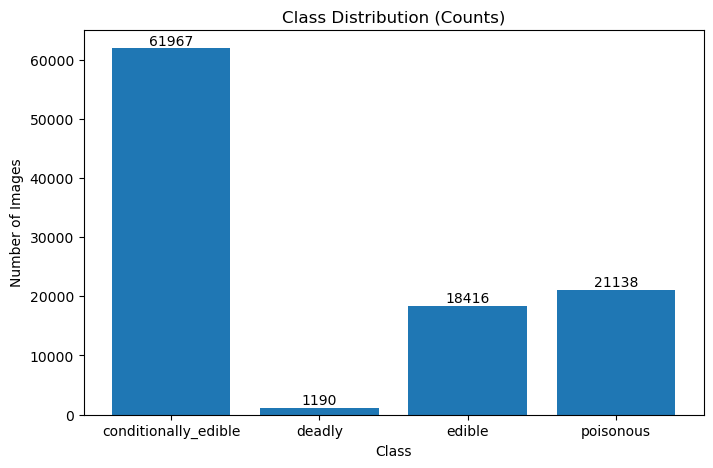

In [28]:
counts = df["class"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
bars = plt.bar(counts.index, counts.values)

plt.title("Class Distribution (Counts)")
plt.xlabel("Class")
plt.ylabel("Number of Images")

# Add count labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.show()

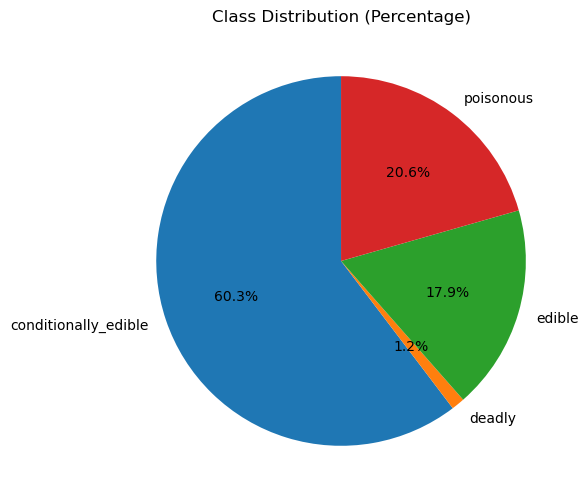

In [29]:
plt.figure(figsize=(6, 6))

plt.pie(
    counts.values,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Class Distribution (Percentage)")
plt.show()

In [30]:
class_dist_table = (
    counts
    .rename("count")
    .to_frame()
)

class_dist_table["percentage"] = (
    class_dist_table["count"] / class_dist_table["count"].sum() * 100
).round(2)

class_dist_table


,count,percentage
class,,
conditionally_edible,61967,60.33
deadly,1190,1.16
edible,18416,17.93
poisonous,21138,20.58


#### Image Size / Resolution distribution

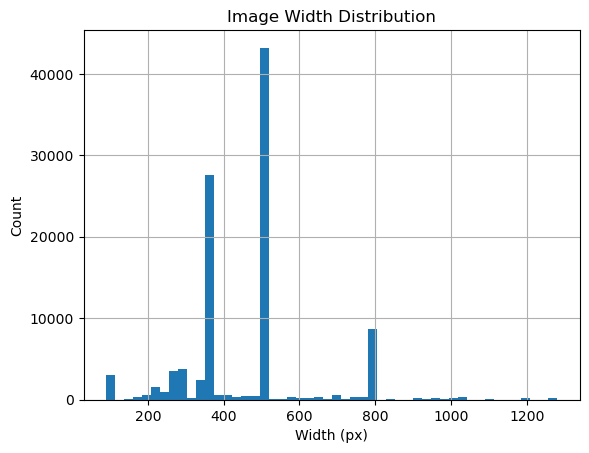

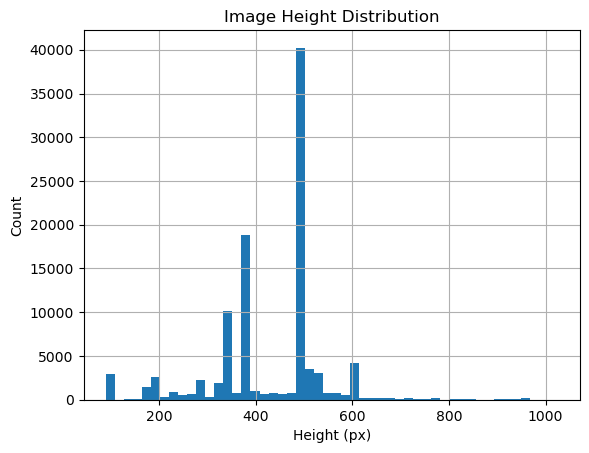

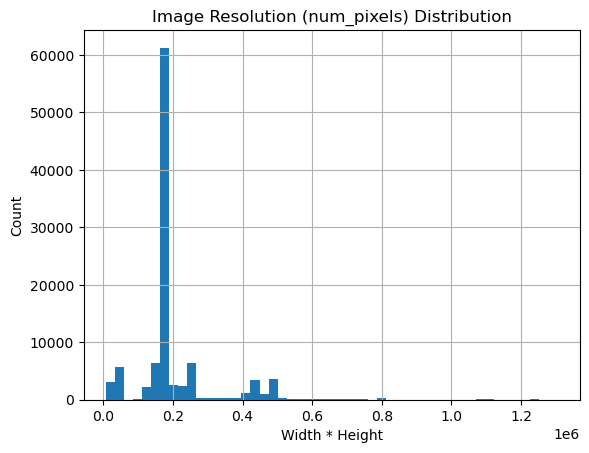

In [31]:
plt.figure()
df["width"].hist(bins=50)
plt.title("Image Width Distribution")
plt.xlabel("Width (px)")
plt.ylabel("Count")
plt.show()

plt.figure()
df["height"].hist(bins=50)
plt.title("Image Height Distribution")
plt.xlabel("Height (px)")
plt.ylabel("Count")
plt.show()

plt.figure()
df["num_pixels"].hist(bins=50)
plt.title("Image Resolution (num_pixels) Distribution")
plt.xlabel("Width * Height")
plt.ylabel("Count")
plt.show()

#### Aspect Ratio + Scatter (spot outliers)

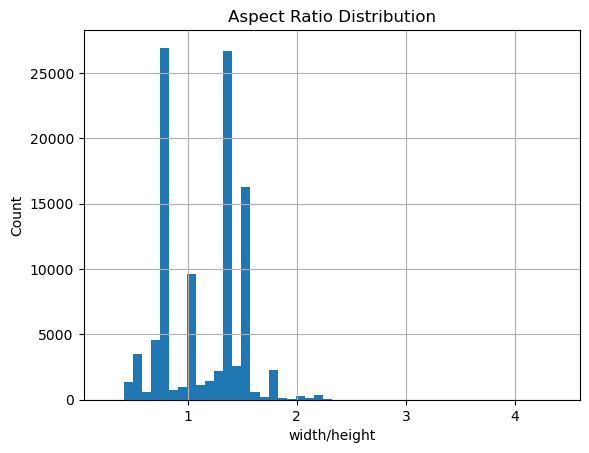

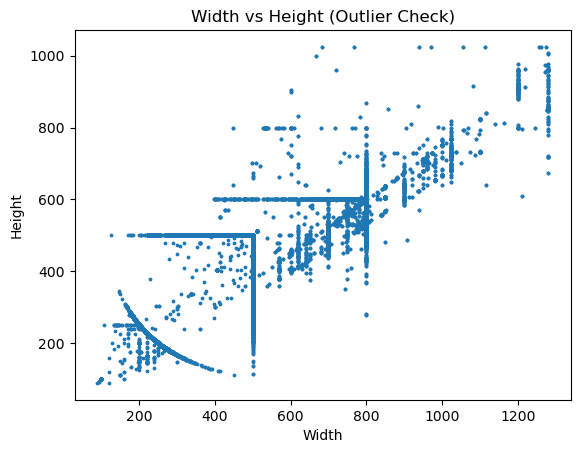

In [32]:
plt.figure()
df["aspect_ratio"].hist(bins=50)
plt.title("Aspect Ratio Distribution")
plt.xlabel("width/height")
plt.ylabel("Count")
plt.show()

# Spot weird sizes/outliers
plt.figure()
plt.scatter(df["width"], df["height"], s=3)
plt.title("Width vs Height (Outlier Check)")
plt.xlabel("Width")
plt.ylabel("Height")
plt.show()


#### Duplicate Check (Exact and Near)

Duplicate and near-duplicate images were identified and removed to reduce redundancy and prevent df leakage between training and evaluation sets.

##### Exact Duplicate Removal
- Perceptual hash (pHash) values were used to identify exact duplicate images.
- Images sharing the same pHash were considered visually identical.
- For each group of exact duplicates, only the image with the highest resolution (largest number of pixels) was retained.
- Lower-resolution duplicates were removed from the dataset.

In [62]:
df_sorted = df.sort_values(["phash", "num_pixels"], ascending=[True, False])

exact_dedup = df_sorted.drop_duplicates(subset=["phash"], keep="first").copy().reset_index(drop=True)

removed = len(df) - len(exact_dedup)
print(f"Rows before: {len(df):,}")
print(f"Rows after : {len(exact_dedup):,}")
print(f"Removed    : {removed:,} ({removed/len(df)*100:.2f}%)")

exact_dedup.to_csv("mushroomDedupExact.csv", index=False)
print("Saved:", "mushroomDedupExact.csv")

Rows before: 102,711
Rows after : 94,698
Removed    : 8,013 (7.80%)
Saved: mushroomDedupExact.csv


##### Near-Duplicate Removal
- Near-duplicate images were identified by computing the Hamming distance between pHash values.
- Images with a Hamming distance below a predefined threshold were considered near-duplicates.
- When near-duplicate images were detected, the image with the highest resolution was retained, and remaining lower-resolution images were removed.

In [63]:
HAMMING_THRESHOLD = 5     # 5 means "very similar"
PREFIX_LEN = 4            # bucket by first 4 hex chars; increase to reduce comparisons

In [64]:
# Convert to ImageHash
hashes = df["phash"].astype(str).apply(imagehash.hex_to_hash)

In [65]:
# Bucket indices by hash prefix to avoid O(N^2)
buckets = defaultdict(list)
for i, h in enumerate(hashes):
    buckets[str(h)[:PREFIX_LEN]].append(i)

keep = set(range(len(df)))
dropped = set()

In [66]:
# Within each bucket, drop near-duplicates by keeping highest resolution
for _, idxs in buckets.items():
    if len(idxs) <= 1:
        continue

    idxs_sorted = sorted(idxs, key=lambda i: df.loc[i, "num_pixels"], reverse=True)

    chosen = []
    for i in idxs_sorted:
        if i in dropped:
            continue
        is_near_dup = any((hashes[i] - hashes[j]) <= HAMMING_THRESHOLD for j in chosen)
        if is_near_dup:
            dropped.add(i)
        else:
            chosen.append(i)

In [67]:
keep = sorted(list(keep - dropped))
near_dedup = df.iloc[keep].copy().reset_index(drop=True)

print(f"Rows before: {len(df):,}")
print(f"Rows after : {len(near_dedup):,}")
print(f"Removed    : {len(df)-len(near_dedup):,} ({(len(df)-len(near_dedup))/len(df)*100:.2f}%)")

near_dedup.to_csv("mushroomDedupNear.csv", index=False)
print("Saved:", "mushroomDedupNear.csv")

Rows before: 94,698
Rows after : 94,631
Removed    : 67 (0.07%)
Saved: mushroomDedupNear.csv


In [68]:
BASE_DIR = Path(".") 

print("raw :", df.shape)
print("exact:", exact_dedup.shape)
print("near :", near_dedup.shape)

raw : (102711, 11)
exact: (94698, 11)
near : (94631, 11)


##### Stat after Deduplication

In [69]:
def exact_dup_stats(df):
    vc = df["phash"].astype(str).value_counts()
    dup_hashes = (vc > 1).sum()
    dup_images = vc[vc > 1].sum()
    return dup_hashes, dup_images

rows = []
for name, d in [("raw", df), ("after_exact", exact_dedup), ("after_near", near_dedup)]:
    dup_hashes, dup_images = exact_dup_stats(d)
    rows.append({
        "dataset": name,
        "n_rows": len(d),
        "hashes_with_count>1": dup_hashes,
        "images_in_exact_dup_groups": int(dup_images),
        "exact_dup_rate": float(dup_images / len(d))
    })

summary = pd.DataFrame(rows)
summary


,dataset,n_rows,hashes_with_count>1,images_in_exact_dup_groups,exact_dup_rate
0,raw,102711,7623,15636,0.152233
1,after_exact,94698,0,0,0.000000
2,after_near,94631,0,0,0.000000


##### Sample of Exact Duplicates Removed

In [70]:
def show_exact_duplicate_group(df, base_dir=BASE_DIR, max_show=6):
    # Count pHash occurrences
    vc = df["phash"].astype(str).value_counts()
    dup_hashes = vc[vc > 1]

    if len(dup_hashes) == 0:
        print("No exact duplicates found.")
        return

    # Take the first duplicate hash as an example
    ph = dup_hashes.index[0]
    group = df[df["phash"].astype(str) == ph].copy()

    # Keep highest-resolution images first
    group = group.sort_values("num_pixels", ascending=False).head(max_show)

    print(f"Example exact-duplicate pHash: {ph}")
    display(group[["file_path", "width", "height", "num_pixels", "class", "species"]])

    plt.figure(figsize=(14, 3))
    for i, (_, row) in enumerate(group.iterrows(), start=1):
        img_path = (base_dir / row["file_path"]).resolve()

        if not img_path.exists():
            raise FileNotFoundError(f"Image not found: {img_path}")

        img = Image.open(img_path).convert("RGB")
        plt.subplot(1, len(group), i)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f'{row["width"]}×{row["height"]}')

    plt.show()


Example exact-duplicate pHash: 965a79b4423b7266


,file_path,width,height,num_pixels,class,species
68621,Classes/poisonous/Amanita_roseotincta/Amanita_roseotincta4.png,100,100,10000,poisonous,Amanita_roseotincta
73590,Classes/poisonous/Amanita_neoovoidea/Amanita_neoovoidea3.png,100,100,10000,poisonous,Amanita_neoovoidea
73618,Classes/poisonous/Amanita_parvipantherina/Amanita_parvipantherina7.png,100,100,10000,poisonous,Amanita_parvipantherina
73776,Classes/poisonous/Amanita_ibotengutake/Amanita_ibotengutake3.png,100,100,10000,poisonous,Amanita_ibotengutake
73825,Classes/poisonous/Amanita_smithiana/Amanita_smithiana2.png,100,100,10000,poisonous,Amanita_smithiana
74007,Classes/poisonous/Amanita_petalinivolva/Amanita_petalinivolva2.png,100,100,10000,poisonous,Amanita_petalinivolva


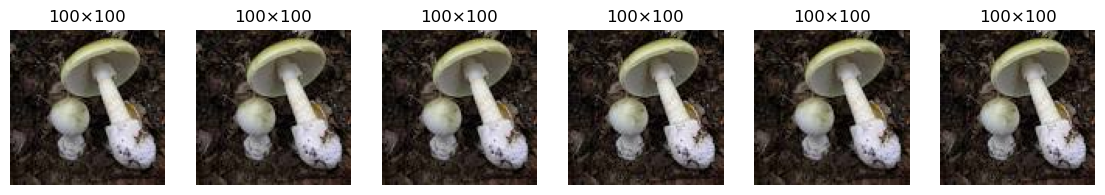

In [71]:
show_exact_duplicate_group(df)

##### Sample of Near Duplicates Removed

In [72]:

def hamming_hex(h1, h2):
    # robust popcount (works on older Python too)
    x = int(h1, 16) ^ int(h2, 16)
    return bin(x).count("1")

def near_dedup_pairs(df, prefix_len=PREFIX_LEN, thresh=HAMMING_THRESHOLD):
    ph = df["phash"].astype(str).tolist()
    
    buckets = defaultdict(list)
    for idx, h in enumerate(ph):
        buckets[h[:prefix_len]].append(idx)

    # return example near-dup pairs (i, j, distance)
    pairs = []
    for idxs in buckets.values():
        if len(idxs) <= 1:
            continue
        # compare within bucket (still can be big, so we limit example output)
        for a_pos in range(len(idxs)):
            for b_pos in range(a_pos + 1, len(idxs)):
                i, j = idxs[a_pos], idxs[b_pos]
                d = hamming_hex(ph[i], ph[j])
                if d <= thresh and d != 0:  # d==0 are exact duplicates
                    pairs.append((i, j, d))
                    if len(pairs) >= 30:  # limit to keep it fast
                        return pairs
    return pairs

pairs = near_dedup_pairs(df)
print("Found near-duplicate pairs (sample):", len(pairs))
pairs[:5]

Found near-duplicate pairs (sample): 30


[(42230, 42236, 2),
 (87756, 87769, 4),
 (87756, 87775, 4),
 (15525, 72883, 2),
 (62735, 102560, 2)]

In [73]:
def show_near_duplicate_example(df, pairs, base_dir=BASE_DIR):
    if not pairs:
        print("No near-duplicate pairs found (or sampling limit reached).")
        return
    
    i, j, d = pairs[0]
    r1 = df.iloc[i]
    r2 = df.iloc[j]
    print("Example near-duplicate pair")
    print("Hamming distance:", d)
    display(pd.DataFrame([r1, r2])[["file_path", "width", "height", "num_pixels", "class", "species", "phash"]])

    plt.figure(figsize=(8, 4))
    for k, row in enumerate([r1, r2], start=1):
        p = base_dir / row["file_path"]
        img = Image.open(p).convert("RGB")
        plt.subplot(1, 2, k)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f'{row["width"]}x{row["height"]}')
    plt.suptitle(f"Near-duplicate example (Hamming={d})")
    plt.show()


Example near-duplicate pair
Hamming distance: 2


,file_path,width,height,num_pixels,class,species,phash
42230,Classes/conditionally_edible/snakeskin_grisette/13.png,512,512,262144,conditionally_edible,snakeskin_grisette,93cb0de47454ca5b
42236,Classes/conditionally_edible/snakeskin_grisette/6.png,512,512,262144,conditionally_edible,snakeskin_grisette,93cb0de47454ea4b


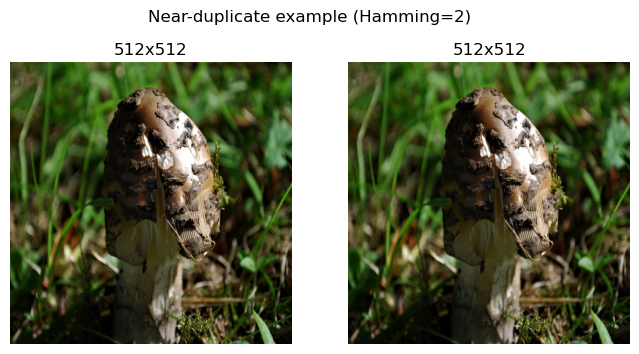

In [74]:
show_near_duplicate_example(df, pairs)

##### Summary

In [75]:
dup_counts = df["phash"].value_counts()
num_dup_hashes = (dup_counts > 1).sum()
num_dup_images = dup_counts[dup_counts > 1].sum()

print("Hashes that appear >1 time:", num_dup_hashes)
print("Images involved in duplicates:", num_dup_images)
print("Duplicate image rate:", num_dup_images / len(df))


Hashes that appear >1 time: 7623
Images involved in duplicates: 15636
Duplicate image rate: 0.15223296433682856


#### Sample Images per Class (visual sanity check)

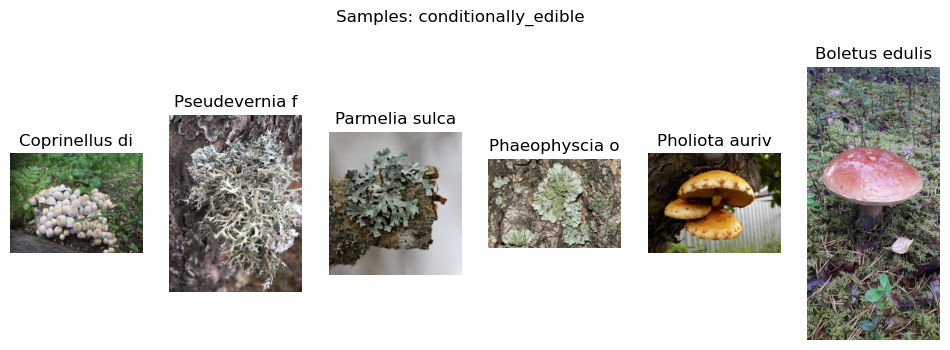

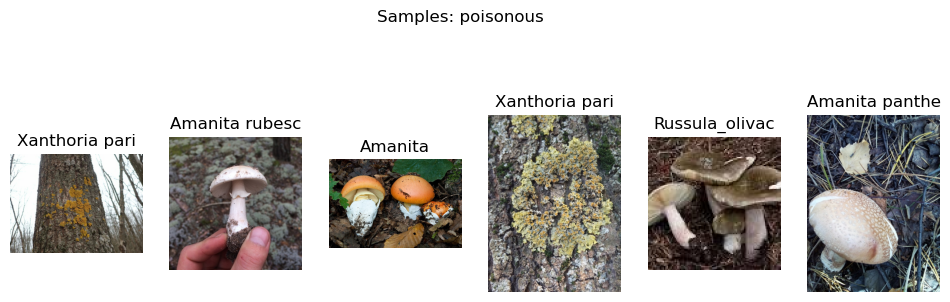

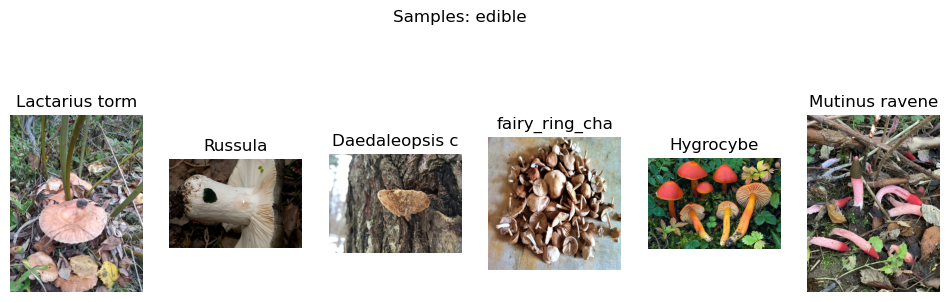

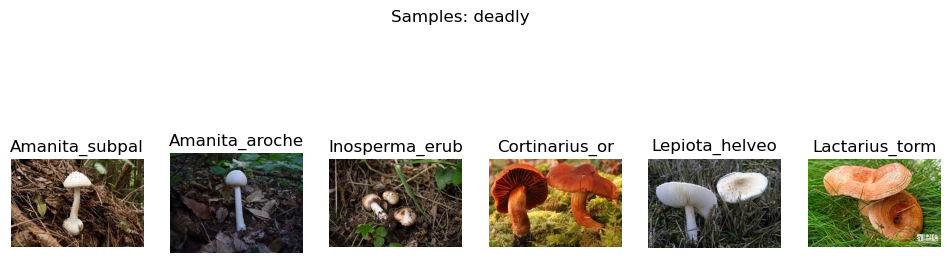

In [76]:
def show_samples(df, class_name, n=6):
    sub = df[df["class"] == class_name].sample(n=min(n, len(df[df["class"] == class_name])), random_state=0)
    plt.figure(figsize=(12, 4))
    for i, (_, row) in enumerate(sub.iterrows(), start=1):
        plt.subplot(1, n, i)
        img = Image.open(row["file_path"]).convert("RGB")
        plt.imshow(img)
        plt.axis("off")
        plt.title(row["species"][:14])
    plt.suptitle(f"Samples: {class_name}")
    plt.show()

for c in df["class"].unique():
    show_samples(df, c, n=6)

### Data Pipeline & Transformations

#### Standardization

Standardization was applied dynamically during df loading to ensure consistent input format for model training. All images were resized to a fixed input resolution to accommodate convolutional neural network requirements. Pixel values were scaled to the range [0, 1] and normalized using predefined channel-wise mean and standard deviation values. This process was deterministic and applied consistently across training, validation, and test datasets.

#### Augmentation
Data augmentation was applied only to the training dataset to improve model robustness and generalization. Random transformations, including horizontal flipping, rotation, and color jittering, were used to introduce controlled variability in image appearance while preserving semantic content. Augmentation was performed at load time and did not modify the original image files.

In [2]:
IMG_SIZE = 224

# RGB statistics of ImageNet
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
    transforms.ToTensor(),  # converts to [0,1]
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

### Model

#### Train-test-validation Split

In [2]:
# near_dedup = pd.read_csv("mushroomDedupNear.csv")

In [3]:
# After exact dedup and exact dedup, the cleaned dataset is the output of near dedup
processed_df = near_dedup.copy()

In [13]:
pd.read_csv("mushroomDedupNear.csv").shape

(94631, 11)

In [14]:
pd.read_csv("mushroomDedupExact.csv").shape

(94698, 11)

In [4]:
train, temp = train_test_split(processed_df, test_size=0.2, random_state=42, stratify=processed_df['class'])
test, val = train_test_split(temp, test_size=0.5, random_state=42, stratify=temp['class'])
train.shape, val.shape, test.shape

((75704, 11), (9464, 11), (9463, 11))

In [8]:
train['class'].value_counts(normalize=True)

class
conditionally_edible    0.612729
poisonous               0.210253
edible                  0.169714
deadly                  0.007305
Name: proportion, dtype: float64

In [9]:
test['class'].value_counts(normalize=True)

class
conditionally_edible    0.612702
poisonous               0.210187
edible                  0.169714
deadly                  0.007397
Name: proportion, dtype: float64

In [10]:
val['class'].value_counts(normalize=True)

class
conditionally_edible    0.612743
poisonous               0.210270
edible                  0.169696
deadly                  0.007291
Name: proportion, dtype: float64

In [67]:
from MushroomDataset import *

In [68]:
train_classes = sorted(train["class"].unique().tolist())
train_class_to_idx = {c: i for i, c in enumerate(train_classes)}

train_ds = MushroomDataset(train, transform=train_tfms, class_to_idx=train_class_to_idx, classes=train_classes)
val_ds = MushroomDataset(val, transform=val_tfms, class_to_idx=train_class_to_idx, classes=train_classes) # ensure same mapping
test_ds = MushroomDataset(test, transform=val_tfms, class_to_idx=train_class_to_idx, classes=train_classes) # ensure same mapping

CLASSES = train_classes

In [69]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [70]:
d_device = torch.device(device)
d_device

device(type='cuda')

In [71]:
BATCH_SIZE = 32
NUM_WORKERS = 4

In [72]:
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=(device=="cuda"))
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(device=="cuda"))
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(device=="cuda"))

##### Class Weights Calculation

To address class imbalance, we apply weighted cross-entropy loss so that misclassifying rare classes incurs a larger penalty.

In [73]:
counts = train["class"].value_counts().reindex(CLASSES).to_numpy()
counts = torch.tensor(counts, dtype=torch.float)
total = counts.sum()

class_weights = total / (len(CLASSES) * counts)
class_weights = class_weights.to(d_device)

print("Train counts + weights:")
for c, n, w in zip(CLASSES, counts.tolist(), class_weights.detach().cpu().tolist()):
    print(f"  {c:20s} count={int(n):7d} weight={w:.4f}")

criterion = nn.CrossEntropyLoss(weight=class_weights)
criterion.weight

Train counts + weights:
  conditionally_edible count=  46386 weight=0.4080
  deadly               count=    553 weight=34.2242
  edible               count=  12848 weight=1.4731
  poisonous            count=  15917 weight=1.1890


tensor([ 0.4080, 34.2242,  1.4731,  1.1890], device='cuda:0')

#### Baseline Model - ResNet18

##### Training and Validation

In [74]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
model = model.to(d_device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

In [75]:
def run_one_epoch(model, loader, criterion, optimizer, device, scaler=None, is_train=False, return_preds=False):
    running_loss = 0.0
    running_correct = 0
    total = 0

    mode = "TRAIN" if is_train else "VAL"
    use_amp = (device == "cuda")

    all_preds, all_labels = [], []

    if is_train:
        model.train()
        for img, labels in loader:
            img = img.to(d_device, non_blocking=True)
            labels = labels.to(d_device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            if use_amp:
                with torch.cuda.amp.autocast(True):
                    outputs = model(img)
                    loss = criterion(outputs, labels)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                outputs = model(img)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

            preds = outputs.argmax(1)
            running_loss += loss.item() * img.size(0)
            running_correct += (preds == labels).sum().item()
            total += img.size(0)

            if return_preds:
                all_preds.append(preds.cpu())
                all_labels.append(labels.cpu())
    else:
        model.eval()
        with torch.no_grad():
            for img, labels in loader:
                img = img.to(d_device, non_blocking=True)
                labels = labels.to(d_device, non_blocking=True)

                outputs = model(img)
                loss = criterion(outputs, labels)

                preds = outputs.argmax(1)
                running_loss += loss.item() * img.size(0)
                running_correct += (preds == labels).sum().item()
                total += img.size(0)

                if return_preds:
                    all_preds.append(preds.cpu())
                    all_labels.append(labels.cpu())

    total_loss = running_loss / max(total, 1)
    total_acc  = running_correct / max(total, 1)

    if return_preds:
        return total_loss, total_acc, total, torch.cat(all_labels), torch.cat(all_preds)
    else:
        return total_loss, total_acc, total, None, None

In [76]:
def train(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, patience=3):
    best_val_loss = float('inf')
    bad_epochs = 0

    use_amp = (device == "cuda")
    print("device = ", device)
    print("use_amp = ", use_amp)
    
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp) if use_amp else None

    for epoch in range(num_epochs):
        print(f"\n>>> Epoch {epoch + 1} start", flush=True)

        train_loss, train_acc, _, _, _ = run_one_epoch(
            model, train_loader, criterion, optimizer, device, scaler=scaler, is_train=True, return_preds=False
        )
        val_loss, val_acc, _, _, _ = run_one_epoch(
            model, val_loader, criterion, optimizer, device, is_train=False, return_preds=False
        )

        print(f"Epoch {epoch + 1}: train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, val_loss={val_loss:.4f}, val_acc={val_acc:.4f}.")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            bad_epochs = 0
            torch.save(model.state_dict(), "best_model.pth")
            print(">>> Saved best model", flush=True)
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                print("Early stopping triggered.", flush=True)
                break

    return model


In [77]:
_ = train(model, train_loader, val_loader, criterion, optimizer, num_epochs=5, device=device, patience=5)

device =  cuda
use_amp =  True

>>> Epoch 1 start
Epoch 1: train_loss=0.8198, train_acc=0.6498, val_loss=0.7445, val_acc=0.7566.
>>> Saved best model

>>> Epoch 2 start
Epoch 2: train_loss=0.7084, train_acc=0.7033, val_loss=0.6799, val_acc=0.6828.
>>> Saved best model

>>> Epoch 3 start
Epoch 3: train_loss=0.6586, train_acc=0.7264, val_loss=0.6140, val_acc=0.7193.
>>> Saved best model

>>> Epoch 4 start
Epoch 4: train_loss=0.5942, train_acc=0.7536, val_loss=0.6682, val_acc=0.7380.

>>> Epoch 5 start
Epoch 5: train_loss=0.5614, train_acc=0.7695, val_loss=0.5533, val_acc=0.7652.
>>> Saved best model


In [78]:
# rebuild model architecture and load best model
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
model = model.to(d_device)
state_dict = torch.load("best_model.pth", map_location=d_device)
model.load_state_dict(state_dict)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

##### Testing

In [79]:
test_loss, test_acc, test_total, test_labels, test_preds = run_one_epoch(
    model, test_loader, criterion, optimizer, device, is_train=False, return_preds=True
)

In [80]:
print("Test accuracy:", test_acc)
print("Balanced accuracy:", balanced_accuracy_score(y_true, y_pred))

Test accuracy: 0.7610694282996936
Balanced accuracy: 0.7531927264717254


In [81]:
cm = confusion_matrix(y_true.numpy(), y_pred.numpy())
print("Confusion matrix:\n", cm)
print("\nClassification report:\n",
    classification_report(y_true.numpy(), y_pred.numpy(), target_names=CLASSES, digits=4))

Confusion matrix:
 [[4334   50 1185  229]
 [   0   66    4    0]
 [ 250  211 1104   41]
 [ 210  367  149 1263]]

Classification report:
                       precision    recall  f1-score   support

conditionally_edible     0.9040    0.7475    0.8184      5798
              deadly     0.0951    0.9429    0.1728        70
              edible     0.4521    0.6874    0.5455      1606
           poisonous     0.8239    0.6350    0.7172      1989

            accuracy                         0.7151      9463
           macro avg     0.5688    0.7532    0.5634      9463
        weighted avg     0.8045    0.7151    0.7460      9463



#### 2nd Model - ResNet50

#### 3rd Model - Swin Transformer Tiny